In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

In [90]:
spark = SparkSession.builder \
    .appName("Project_Results_View") \
    .getOrCreate()

In [92]:
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Experimental Analysis of Results
This notebook analyzes performance metrics collected while running analytics jobs (1 - MapReduce, 2 - Hive, 3 - Spark) on the `flight_delay_2024` dataset.

The analysis compares execution times in the local environment and on AWS clusters (from 4 nodes up to 16), evaluating efficiency, scalability, and the impact of operations on the data.

## ETL and Data Preparation
The data preparation phase consisted of two steps: cleansing and sample dataset generation, each using a dedicated Python script:
* the cleansing script processed the entire original dataset (over 7 million rows), eliminating 17.499 malformed records.
* the generation script generated 7 sampling datasets (10%, 25%, 50%, 75%, 150%, 200%, 300%) obtained by partitioning or replicating the original, clean dataset in a controlled manner.

Saving the output in Parquet format ensured high compression and optimization during columnar reading, essential for subsequent jobs.

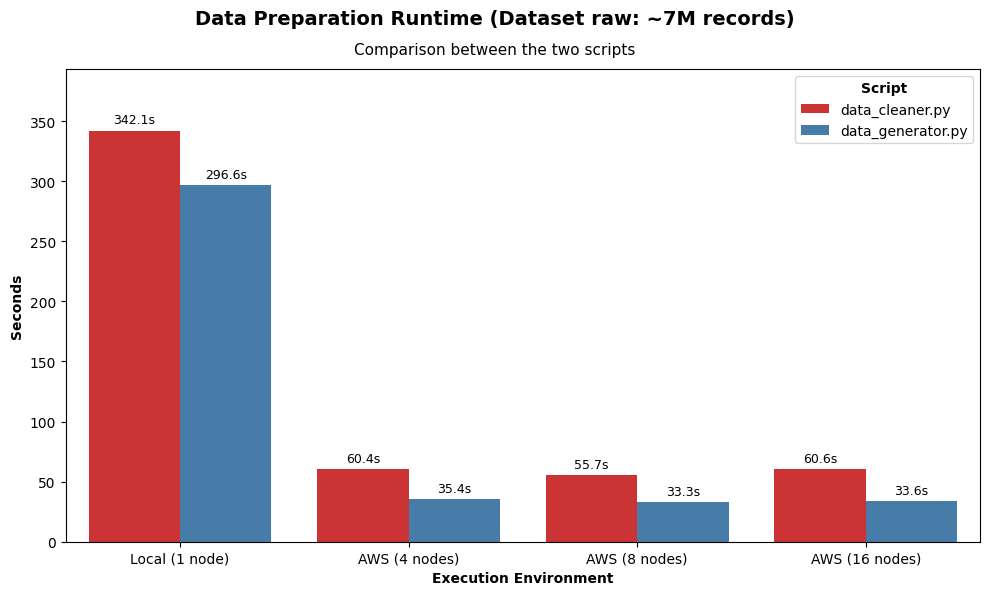

In [ ]:
data_combined = pd.DataFrame({
    'Environment': ['Local (1 node)', 'AWS (4 nodes)', 'AWS (8 nodes)', 'AWS (16 nodes)'] * 2,
    'Script': ['data_cleaner.py'] * 4 + ['data_generator.py'] * 4,
    'Execution_Time_Sec': [
        # Data Cleaner times
        342.086, 60.380, 55.731, 60.609,
        # Data Generator times
        296.611, 35.446, 33.259, 33.631 
    ]
})

plt.figure(figsize=(10, 6))

ax1 = sns.barplot(
    data=data_combined, 
    x='Environment', 
    y='Execution_Time_Sec', 
    hue='Script', 
    palette='Set1'
)

max_height = data_combined['Execution_Time_Sec'].max()
ax1.set_ylim(0, max_height * 1.15) 

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1fs', padding=3, fontsize=9)

plt.figtext(0.5, 0.96, 'Data Preparation Runtime (Dataset raw: ~7M records)', ha='center', fontweight='bold', fontsize=14)
plt.figtext(0.5, 0.91, 'Comparison between the two scripts', ha='center', fontsize=11)

plt.ylabel('Seconds', fontweight='bold')
plt.xlabel('Execution Environment', fontweight='bold')
plt.legend(title='Script', title_fontproperties={'weight': 'bold'})

plt.tight_layout(rect=[0, 0, 1, 0.91]) 
plt.show()

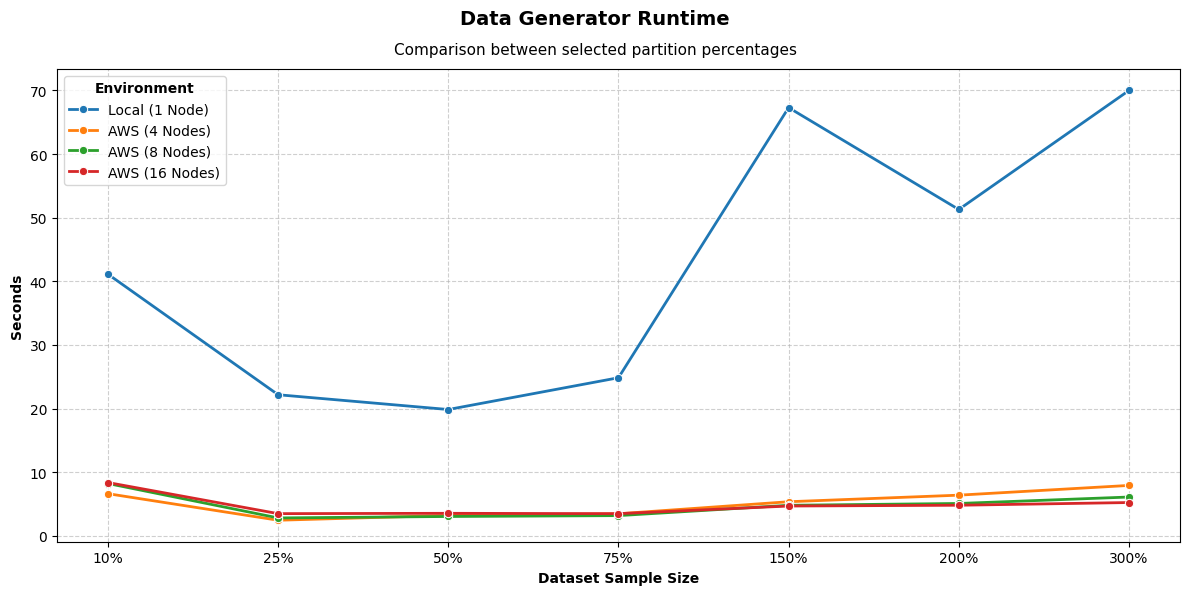

In [83]:
gen_data = {
    'Environment': ['Local (1 Node)']*7 + ['AWS (4 Nodes)']*7 + ['AWS (8 Nodes)']*7 + ['AWS (16 Nodes)']*7,
    'Generated_Dataset': ['10%', '25%', '50%', '75%', '150%', '200%', '300%'] * 4,
    'Execution_Time_Sec': [
        # Local_1
        41.126, 22.178, 19.856, 24.850, 67.308, 51.294, 69.999,
        # AWS_4Nodes
        6.626, 2.454, 3.212, 3.472, 5.362, 6.395, 7.925,
        # AWS_8Nodes
        8.225, 2.816, 3.044, 3.181, 4.802, 5.089, 6.102,
        # AWS_16Nodes
        8.379, 3.490, 3.542, 3.485, 4.688, 4.811, 5.236
    ]
}

df_gen = pd.DataFrame(gen_data)

plt.figure(figsize=(12, 6))

ax2 = sns.lineplot(
    data=df_gen, 
    x='Generated_Dataset', 
    y='Execution_Time_Sec', 
    hue='Environment', 
    marker='o',
    linewidth=2,
    palette='tab10'
)

plt.figtext(0.5, 0.96, 'Data Generator Runtime', ha='center', fontweight='bold', fontsize=14)
plt.figtext(0.5, 0.91, 'Comparison between selected partition percentages', ha='center', fontsize=11)

plt.ylabel('Seconds', fontweight='bold')
plt.xlabel('Dataset Sample Size', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Environment', title_fontproperties={'weight': 'bold'})

plt.tight_layout(rect=[0, 0, 1, 0.91]) 
plt.show()

## Efficiency as the Cluster Size Variation
The empirical results reveal interesting dynamics regarding **framework overhead**.

The observations were made by analyzing the `flight_10` dataset, noting in particular that:
* MapReduce (Job 1) performed quickly locally, while on the cluster it suffered from the cost of allocating YARN containers.
* Spark (Job 3) proved to be the most efficient engine overall on the cluster thanks to in-memory processing.
* Hive (Job 2) benefits from the cluster but suffers from inherent task startup latency.

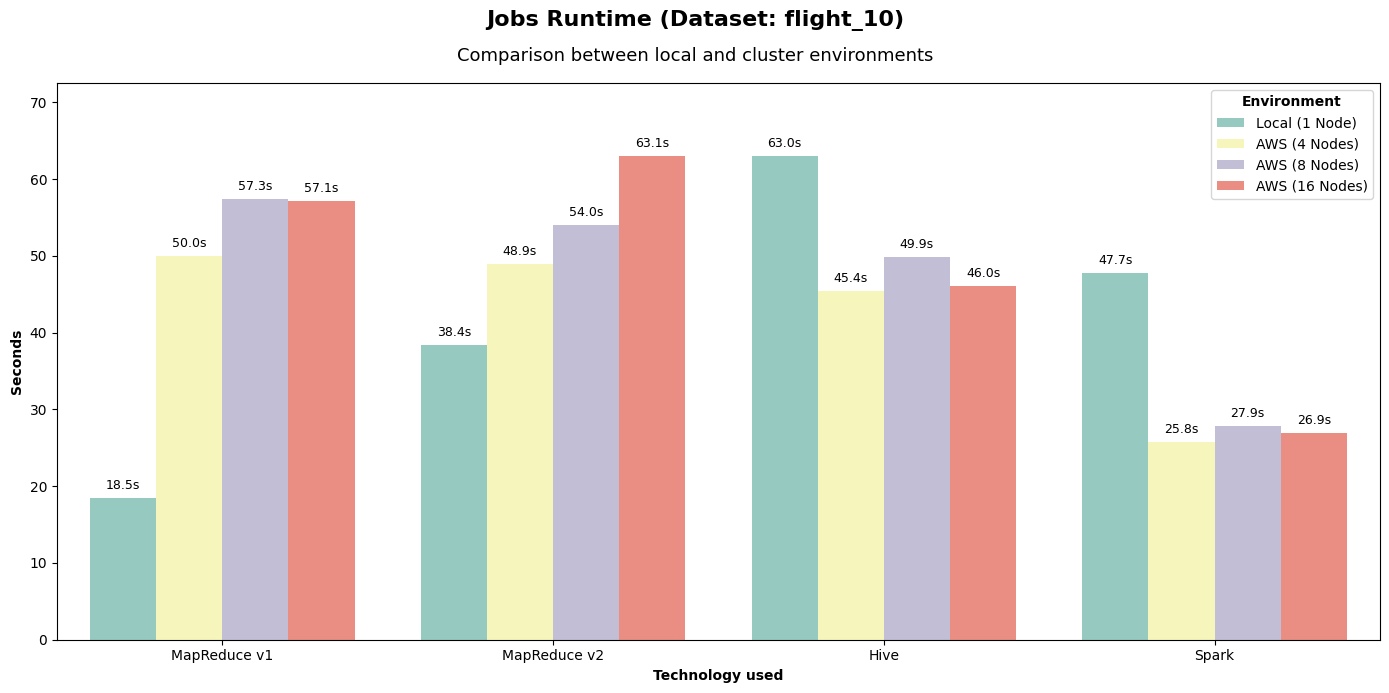

In [81]:
# dataset flight_10
efficiency_df = pd.DataFrame({
    'Technology': [
        'MapReduce v1', 'MapReduce v1', 'MapReduce v1', 'MapReduce v1',
        'MapReduce v2', 'MapReduce v2', 'MapReduce v2', 'MapReduce v2',
        'Hive', 'Hive', 'Hive', 'Hive',
        'Spark', 'Spark', 'Spark', 'Spark'
    ],
    'Environment': [
        'Local (1 Node)', 'AWS (4 Nodes)', 'AWS (8 Nodes)', 'AWS (16 Nodes)',
        'Local (1 Node)', 'AWS (4 Nodes)', 'AWS (8 Nodes)', 'AWS (16 Nodes)',
        'Local (1 Node)', 'AWS (4 Nodes)', 'AWS (8 Nodes)', 'AWS (16 Nodes)',
        'Local (1 Node)', 'AWS (4 Nodes)', 'AWS (8 Nodes)', 'AWS (16 Nodes)'
    ],
    'Time_Sec': [
        18.478, 50.031, 57.349, 57.115,
        38.355, 48.946, 53.975, 63.062,
        63.014, 45.389, 49.885, 46.037,
        47.720, 25.785, 27.852, 26.922
    ]
})

plt.figure(figsize=(14, 7))

ax = sns.barplot(data=efficiency_df, x='Technology', y='Time_Sec', hue='Environment', palette='Set3')

plt.figtext(0.5, 0.96, 'Jobs Runtime (Dataset: flight_10)', ha='center', fontweight='bold', fontsize=16)
plt.figtext(0.5, 0.91, 'Comparison between local and cluster environments', ha='center', fontsize=13)

plt.ylabel('Seconds', fontweight='bold')
plt.xlabel('Technology used', fontweight='bold')
plt.legend(title='Environment', title_fontproperties={'weight': 'bold'})

max_height = efficiency_df['Time_Sec'].max()
ax.set_ylim(0, max_height * 1.15) 

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}s',
                    (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.90]) 
plt.show()

## Impact of Shuffle Operations in MapReduce
The impact of partitioning and data exchange over the network (*Shuffle*) was analyzed by comparing the two versions of Job 1.

Examining the `flight_25` dataset on the AWS cluster, we observed that:
* **v1** generated less network traffic and produced fewer output records in the Reduce phase.
* **v2** generated greater network traffic (Shuffle Bytes) and more verbose output, resulting in a slight increase in execution and work times for the Reducers.

This factually demonstrates how, in a distributed environment, minimizing the data passed from the Mapper to the Reducer is the true architectural bottleneck.

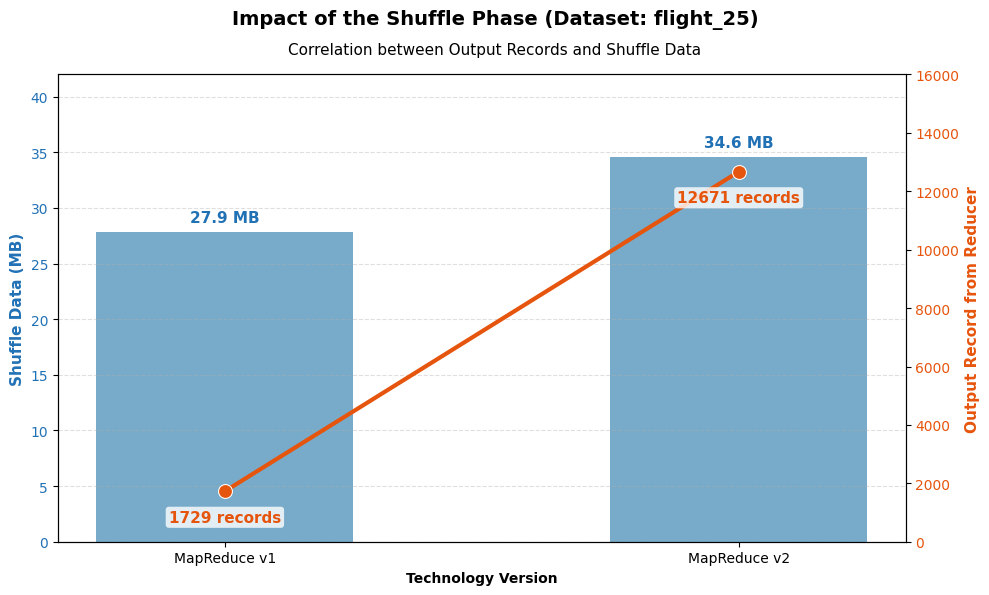

In [69]:
# dataset flight_25
shuffle_df = pd.DataFrame({
    'Version': ['MapReduce v1', 'MapReduce v2'],
    'Shuffle_Bytes_MB': [29238682 / (1024*1024), 36304914 / (1024*1024)], 
    'Record_Output': [1729, 12671]
})

fig, ax1 = plt.subplots(figsize=(10, 6))

color_bar = '#6baed6' 
ax1.set_ylabel('Shuffle Data (MB)', color='#2171b5', fontweight='bold', fontsize=11)
sns.barplot(data=shuffle_df, x='Version', y='Shuffle_Bytes_MB', color=color_bar, ax=ax1, width=0.5)
ax1.tick_params(axis='y', labelcolor='#2171b5')
ax1.set_ylim(0, 42) 

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.1f} MB',
                (p.get_x() + p.get_width() / 2., height),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points', color='#2171b5', fontweight='bold', fontsize=11)

ax2 = ax1.twinx()  
color_line = '#e6550d' 
ax2.set_ylabel('Output Record from Reducer', color=color_line, fontweight='bold', fontsize=11)  
sns.lineplot(data=shuffle_df, x='Version', y='Record_Output', color=color_line, marker='o', linewidth=3, markersize=10, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 16000) 

for x, y in zip(range(len(shuffle_df)), shuffle_df['Record_Output']):
    ax2.annotate(f'{y} records', 
                 (x, y), 
                 textcoords="offset points", 
                 xytext=(0, -22),
                 ha='center', 
                 fontsize=11, 
                 color=color_line, 
                 fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

ax1.set_xlabel('Technology Version', fontweight='bold')

plt.figtext(0.5, 0.96, 'Impact of the Shuffle Phase (Dataset: flight_25)', ha='center', fontweight='bold', fontsize=14)
plt.figtext(0.5, 0.91, 'Correlation between Output Records and Shuffle Data', ha='center', fontsize=11)

ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.91])  
plt.show()

## Scalability as the Dataset Size Variation
To evaluate the frameworks' horizontal scalability, tests were run on increasing portions of the original dataset while maintaining a fixed execution environment.

The results obtained on the 4-node AWS cluster show a counterintuitive but typical trend for Big Data systems:
* **MapReduce v1** maintains constant times regardless of the doubling of data.
* **Spark** increases from 25.7s to 27.3s, suggesting that the increase in data volume was absorbed almost entirely by in-memory parallelism.
* **Hive** even shows a slight decrease in times, attributable to network fluctuations, AWS internal caching, or optimizations of the underlying Tez/MapReduce engine on Parquet files.

This demonstrates that, at these magnitudes, the **bottleneck is the resource allocation overhead (YARN/Spark Context)** and not I/O-bound processing.

The cluster is largely underutilized and could scale to gigabyte/terabyte datasets with linear and proportional time variations.

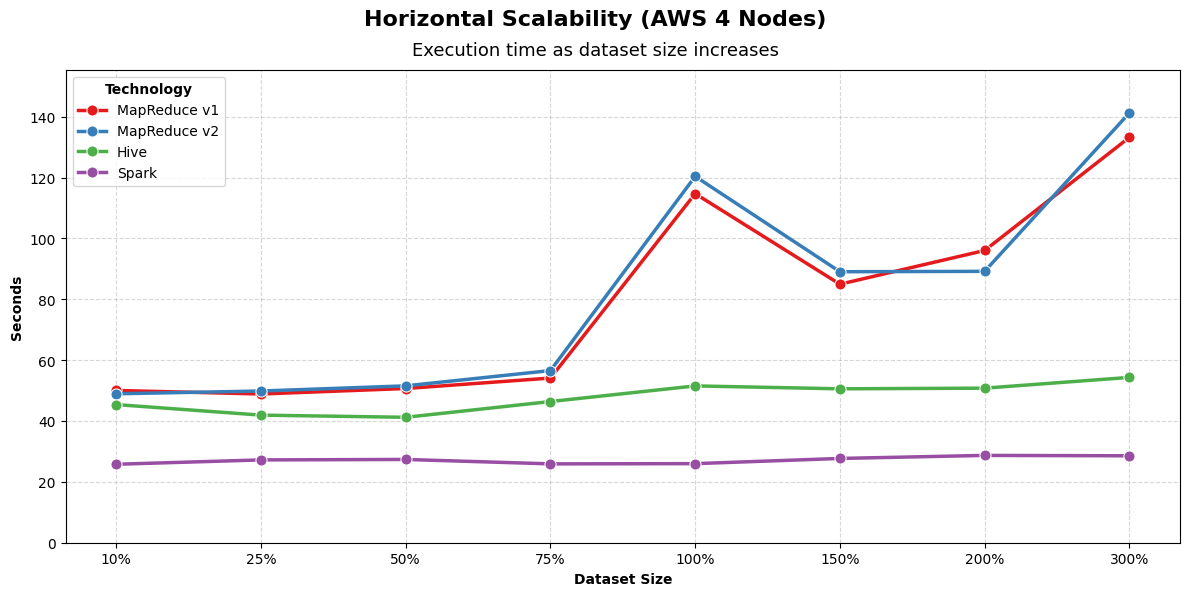

In [85]:
dataset_sizes = ['10%', '25%', '50%', '75%', '100%', '150%', '200%', '300%']

scalability_df = pd.DataFrame({
    'Dataset_Size': dataset_sizes * 4,
    'Technology': ['MapReduce v1']*8 + ['MapReduce v2']*8 + ['Hive']*8 + ['Spark']*8,
    'Time_Sec': [
        # MapReduce v1
        50.031, 48.869, 50.677, 54.110, 114.702, 84.948, 96.026, 133.185,
        # MapReduce v2
        48.946, 49.850, 51.547, 56.572, 120.384, 89.050, 89.177, 141.214,
        # Hive
        45.389, 41.927, 41.216, 46.396, 51.528, 50.574, 50.793, 54.326,
        # Spark
        25.785, 27.211, 27.363, 25.911, 25.985, 27.693, 28.692, 28.565
    ]
})

plt.figure(figsize=(12, 6))

ax = sns.lineplot(data=scalability_df, x='Dataset_Size', y='Time_Sec', 
                  hue='Technology', marker='o', linewidth=2.5, markersize=8, palette='Set1')

plt.figtext(0.5, 0.96, 'Horizontal Scalability (AWS 4 Nodes)', ha='center', fontweight='bold', fontsize=16)
plt.figtext(0.5, 0.91, 'Execution time as dataset size increases', ha='center', fontsize=13)

plt.ylabel('Seconds', fontweight='bold')
plt.xlabel('Dataset Size', fontweight='bold')
plt.legend(title='Technology', title_fontproperties={'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.5)

max_height = scalability_df['Time_Sec'].max()
plt.ylim(0, max_height * 1.1) 

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

# Viewing of Results
Below are the first 10 rows of results produced by each of the three implemented jobs.

## Data Preparation

In [96]:
absolute_path_cleaned = os.path.abspath("../dataset/processed/flight_100.parquet")
file_path_cleaned = f"file://{absolute_path_cleaned}"

df_cleaned = spark.read.parquet(file_path_cleaned)

preview_cleaned = df_cleaned.limit(10).toPandas()
display(preview_cleaned)

,distance,dep_delay,arr_delay,month,cancelled,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,op_unique_carrier,origin,dest,cancellation_code,hour
0,655.0,NaN,NaN,5,1,0,0,0,0,0,OO,ORD,ABE,B,13
1,685.0,NaN,NaN,1,1,0,0,0,0,0,G4,BNA,ABE,B,19
2,486.0,NaN,NaN,10,1,0,0,0,0,0,WN,LAS,ABQ,A,8
3,1269.0,NaN,NaN,7,1,0,0,0,0,0,DL,ATL,ABQ,A,9
4,1118.0,NaN,NaN,6,1,0,0,0,0,0,AA,ORD,ABQ,A,10
5,569.0,NaN,NaN,1,1,0,0,0,0,0,AA,DFW,ABQ,B,10
6,569.0,NaN,NaN,5,1,0,0,0,0,0,MQ,DFW,ABQ,B,13
7,1180.0,NaN,NaN,1,1,0,0,0,0,0,AS,SEA,ABQ,A,14
8,569.0,NaN,NaN,7,1,0,0,0,0,0,AA,DFW,ABQ,A,15
9,759.0,NaN,NaN,1,1,0,0,0,0,0,WN,HOU,ABQ,B,16


## Job 1

In [ ]:
absolute_path_job1 = os.path.abspath("../results/job1_mapreduce/job1_v1/flight_100/part-r-00000")
file_path_job1 = f"file://{absolute_path_job1}"

df_raw = spark.read.csv(file_path_job1, sep="\t", header=False, inferSchema=False)
df_raw = df_raw.toDF("Key", "Value")

df_final_job1 = df_raw.select(
    F.split(F.col("Key"), ",").getItem(0).alias("op_unique_carrier"),
    F.split(F.col("Key"), ",").getItem(1).alias("origin"),
    
    F.regexp_extract(F.col("Value"), r"Flights Operated:\s*(\d+)", 1).cast("int").alias("total_flights"),
    F.regexp_extract(F.col("Value"), r"Min Arr Delay:\s*([\-\d\.]+)", 1).cast("float").alias("min_arr_delay"),
    F.regexp_extract(F.col("Value"), r"Max Arr Delay:\s*([\-\d\.]+)", 1).cast("float").alias("max_arr_delay"),
    F.regexp_extract(F.col("Value"), r"Avg Arr Delay:\s*([\-\d\.]+)", 1).cast("float").alias("avg_arr_delay"),
    F.regexp_extract(F.col("Value"), r"Cancel Rate:\s*([\-\d\.]+)", 1).cast("float").alias("cancelation_rate"),
    F.regexp_extract(F.col("Value"), r"Months of operation:\s*\[(.*?)\]", 1).alias("months_of_operation")
)

preview_job1 = df_final_job1.limit(10).toPandas()
display(preview_job1)

,op_unique_carrier,origin,total_flights,min_arr_delay,max_arr_delay,avg_arr_delay,cancelation_rate,months_of_operation
0,9E,ABE,1015,-47.0,575.0,0.67,1.38,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
1,9E,ABY,38,-32.0,321.0,4.37,0.00,"1, 2, 3, 11, 12"
2,9E,AEX,877,-34.0,979.0,9.61,1.03,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
3,9E,AGS,1602,-36.0,1091.0,6.97,2.06,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
4,9E,ALB,1088,-51.0,394.0,-4.39,1.93,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
5,9E,ATL,26798,-43.0,1207.0,2.46,1.09,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
6,9E,ATW,175,-34.0,420.0,9.39,0.00,"1, 4, 5, 6, 7, 8, 9, 10"
7,9E,AUS,379,-35.0,1225.0,14.15,0.53,"1, 2, 3, 4, 5, 6, 7, 11"
8,9E,AVL,672,-43.0,949.0,1.92,2.08,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
9,9E,AZO,14,-22.0,71.0,-2.93,0.00,1


In [111]:
absolute_path_job1_v2 = os.path.abspath("../results/job1_mapreduce/job1_v2/flight_100/part-r-00000")
file_path_job1_v2 = f"file://{absolute_path_job1_v2}"

df_raw_v2 = spark.read.csv(file_path_job1_v2, sep="\t", header=False, inferSchema=False)
df_raw_v2 = df_raw_v2.toDF("Key", "Value")

df_final_v2 = df_raw_v2.select(
    F.split(F.col("Key"), ",").getItem(0).alias("Carrier"),
    F.split(F.col("Key"), ",").getItem(1).alias("Route"),
    
    F.regexp_extract(F.col("Value"), r"Flights Operated:\s*(\d+)", 1).cast("int").alias("total_flights"),
    F.regexp_extract(F.col("Value"), r"Min Arr Delay:\s*([\-\d\.]+)", 1).cast("float").alias("min_arr_delay"),
    F.regexp_extract(F.col("Value"), r"Max Arr Delay:\s*([\-\d\.]+)", 1).cast("float").alias("max_arr_delay"),
    F.regexp_extract(F.col("Value"), r"Avg Arr Delay:\s*([\-\d\.]+)", 1).cast("float").alias("avg_arr_delay"),
    F.regexp_extract(F.col("Value"), r"Cancel Rate:\s*([\-\d\.]+)", 1).cast("float").alias("cancelation_rate"),
    F.regexp_extract(F.col("Value"), r"Months of operation:\s*\[(.*?)\]", 1).alias("months_of_operation")
)

preview_v2 = df_final_v2.limit(10).toPandas()
display(preview_v2)

,Carrier,Route,total_flights,min_arr_delay,max_arr_delay,avg_arr_delay,cancelation_rate,months_of_operation
0,9E,ABE-ATL,1015,-47.0,575.0,0.67,1.38,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
1,9E,ABY-ATL,38,-32.0,321.0,4.37,0.00,"1, 2, 3, 11, 12"
2,9E,AEX-ATL,877,-34.0,979.0,9.61,1.03,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
3,9E,AGS-ATL,1579,-36.0,1091.0,6.89,2.09,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
4,9E,AGS-AUS,2,12.0,92.0,52.00,0.00,4
5,9E,AGS-DCA,2,21.0,146.0,83.50,0.00,4
6,9E,AGS-DTW,6,-15.0,9.0,-3.17,0.00,4
7,9E,AGS-JFK,2,-3.0,44.0,20.50,0.00,4
8,9E,AGS-LGA,11,-17.0,43.0,-1.00,0.00,4
9,9E,ALB-DTW,435,-51.0,394.0,-4.31,0.46,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"


## Job 2

In [113]:
absolute_path_job2 = os.path.abspath("../results/job2_hive/flight_100.csv")
file_path_job2 = f"file://{absolute_path_job2}"

df_job2 = spark.read.csv(
    file_path_job2, 
    header=True, 
    inferSchema=True, 
    nullValue="\\N"
)

df_final_job2 = df_job2.select(
    F.col("origin").alias("origin"),
    F.col("month").alias("month"),
    F.col("delay_band").alias("delay_band"),
    F.col("total_flights").alias("total_flights"),
    F.col("avg_dep_delay").alias("avg_dep_delay"),
    F.col("avg_arr_delay").alias("avg_arr_delay"),
    F.col("top_cause_1").alias("top_cause_1"),
    F.col("top_cause_2").alias("top_cause_2"),
    F.col("top_cause_3").alias("top_cause_3")
)

preview_job2 = df_final_job2.limit(10).toPandas()
display(preview_job2)

,origin,month,delay_band,total_flights,avg_dep_delay,avg_arr_delay,top_cause_1,top_cause_2,top_cause_3
0,ABE,1,HIGH,30,241.30,234.03,LATE_AIRCRAFT,CARRIER,NAS
1,ABE,1,LOW,275,-5.51,-14.56,NAS,CARRIER,None
2,ABE,1,MEDIUM,30,34.90,32.50,LATE_AIRCRAFT,CARRIER,NAS
3,ABE,1,UNKNOWN,11,NaN,NaN,CANCELLED_B,None,None
4,ABE,2,HIGH,14,227.93,217.93,CARRIER,LATE_AIRCRAFT,NAS
5,ABE,2,LOW,296,-6.62,-19.57,NAS,CARRIER,WEATHER
6,ABE,2,MEDIUM,19,28.53,10.11,CARRIER,LATE_AIRCRAFT,None
7,ABE,2,UNKNOWN,3,NaN,NaN,CANCELLED_B,None,None
8,ABE,3,HIGH,23,173.43,163.39,CARRIER,LATE_AIRCRAFT,NAS
9,ABE,3,LOW,339,-6.19,-18.37,NAS,None,None


## Job 3

In [118]:
absolute_path_job3 = os.path.abspath("../results/job3_spark/flight_100/") 
file_path_job3 = f"file://{absolute_path_job3}"

df_job3 = spark.read.parquet(file_path_job3)

# Rinominiamo le colonne per averle in italiano come richiesto dal progetto
df_job3_ita = df_job3.select(
    df_job3["origin"].alias("origin"),
    df_job3["op_unique_carrier"].alias("op_unique_carrier"),
    df_job3["total_flights"].alias("total_flights"),
    df_job3["avg_dep_delay"].alias("avg_dep_delay"),
    df_job3["avg_arr_delay"].alias("avg_arr_delay"),
    df_job3["cancellation_rate"].alias("cancellation_rate"),
    df_job3["airport_avg_dep_delay"].alias("airport_avg_dep_delay"),
    df_job3["diff_from_airport_avg"].alias("diff_from_airport_avg"),
    df_job3["carrier_rank"].alias("carrier_rank")
)
    
df_final_job3 = df_job3_ita.orderBy("origin", "carrier_rank")

preview_job3 = df_final_job3.limit(10).toPandas()
display(preview_job3)

,origin,op_unique_carrier,total_flights,avg_dep_delay,avg_arr_delay,cancellation_rate,airport_avg_dep_delay,diff_from_airport_avg,carrier_rank
0,ABE,G4,1829,8.32,0.64,1.64,12.12,-3.80,1
1,ABE,9E,1015,9.44,0.67,1.38,12.12,-2.68,2
2,ABE,OH,1163,15.60,4.45,1.29,12.12,3.48,3
3,ABE,OO,311,30.59,22.31,3.86,12.12,18.47,4
4,ABI,MQ,1756,7.31,4.41,0.85,7.31,0.00,1
5,ABQ,DL,1544,1.75,-5.60,0.91,9.44,-7.69,1
6,ABQ,OO,3980,2.08,-2.05,0.45,9.44,-7.36,2
7,ABQ,MQ,904,5.29,3.26,0.66,9.44,-4.15,3
8,ABQ,UA,1817,5.51,-0.32,1.05,9.44,-3.93,4
9,ABQ,AS,422,8.41,4.53,0.95,9.44,-1.03,5
